In [28]:
import sqlite3
import matplotlib.pyplot as plt

In [29]:
conn = sqlite3.connect("pdf_text.db")
cursor = conn.cursor()

degree = cursor.execute("SELECT DISTINCT degree FROM tags").fetchall()
degree = [i[0] for i in degree]
print(degree)

[9, 5, 7, 3, 6, 4, 8, 2, 1, 10, 11]


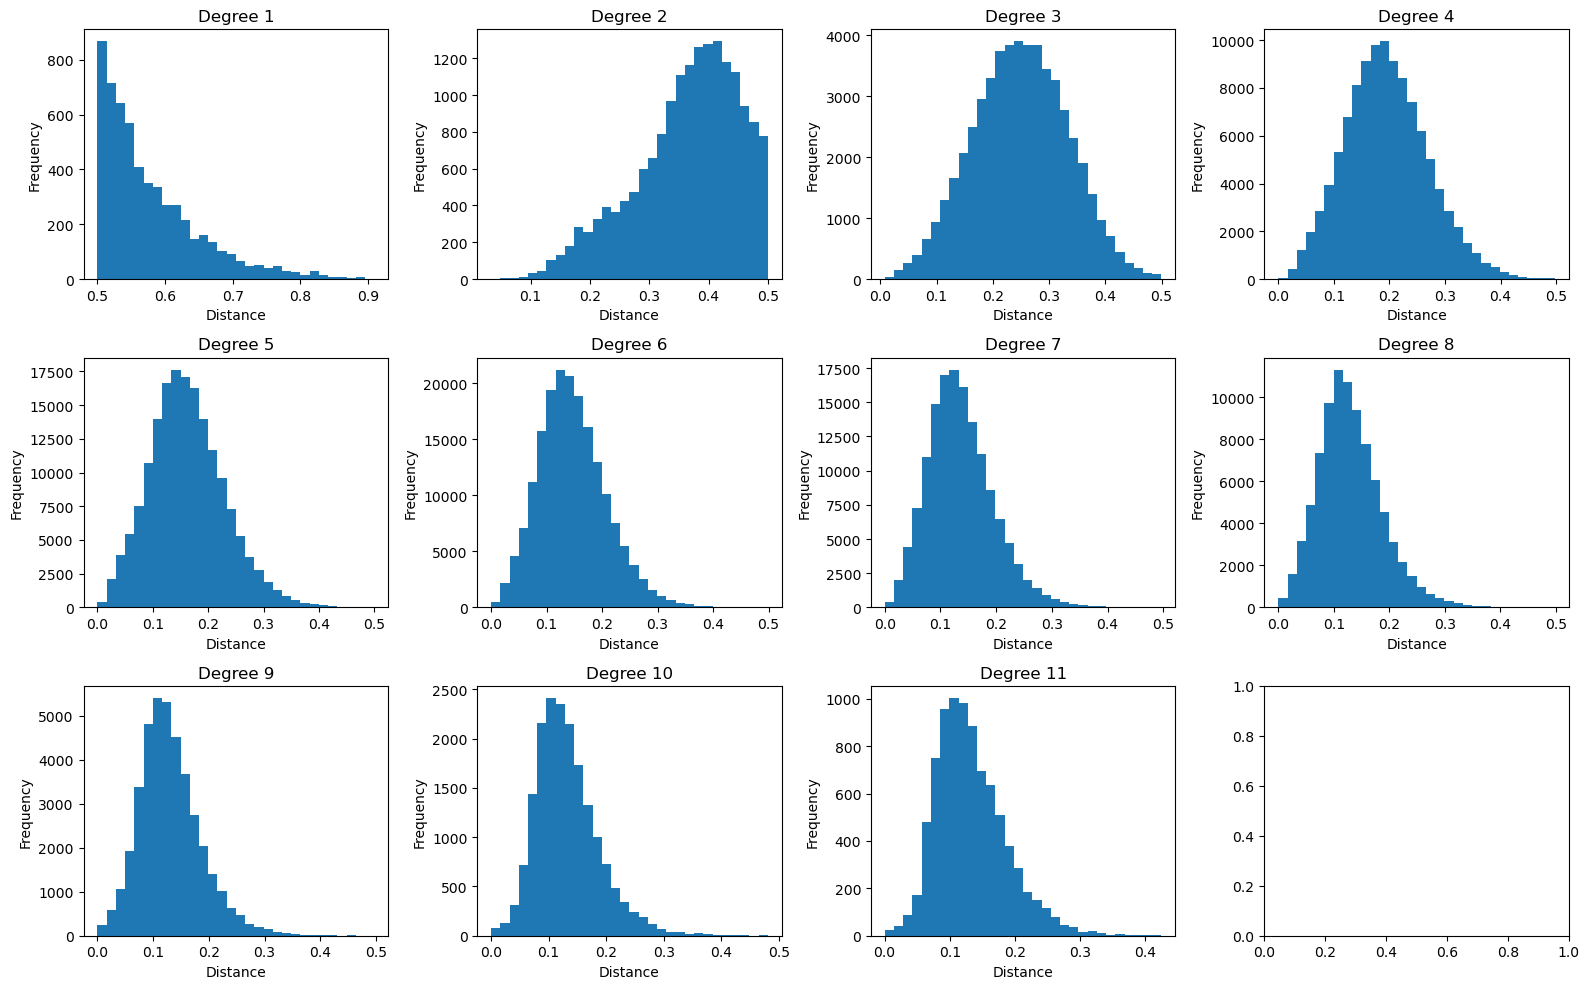

In [30]:
sorted_degree = sorted(degree)

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, level in enumerate(sorted_degree):
    data = cursor.execute(
        "SELECT distance FROM tags WHERE degree = ?", (level,)
    ).fetchall()

    data = [row[0] for row in data]

    axes[i].hist(data, bins=30)
    axes[i].set_title(f"Degree {level}")
    axes[i].set_xlabel("Distance")
    axes[i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

Text(0, 0.5, 'Frequency')

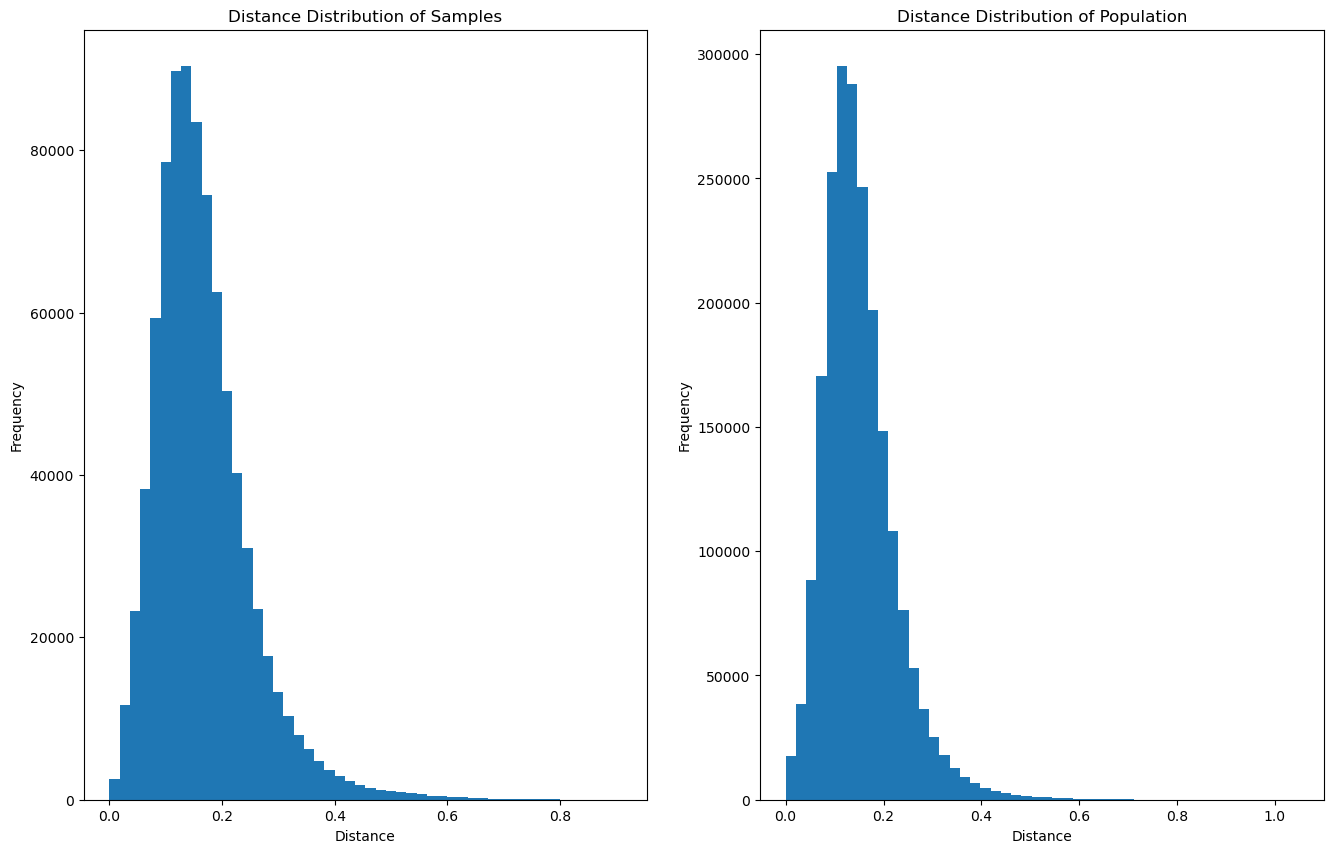

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(16, 10))
axes = axes.flatten()

distance = cursor.execute("SELECT distance FROM tags")
distance = [row[0] for row in distance]

axes[0].hist(distance, bins=50)
axes[0].set_title("Distance Distribution of Samples")
axes[0].set_xlabel("Distance")
axes[0].set_ylabel("Frequency")

distance = cursor.execute("SELECT distance FROM tags_full")
distance = [row[0] for row in distance]

axes[1].hist(distance, bins=50)
axes[1].set_title("Distance Distribution of Population")
axes[1].set_xlabel("Distance")
axes[1].set_ylabel("Frequency")

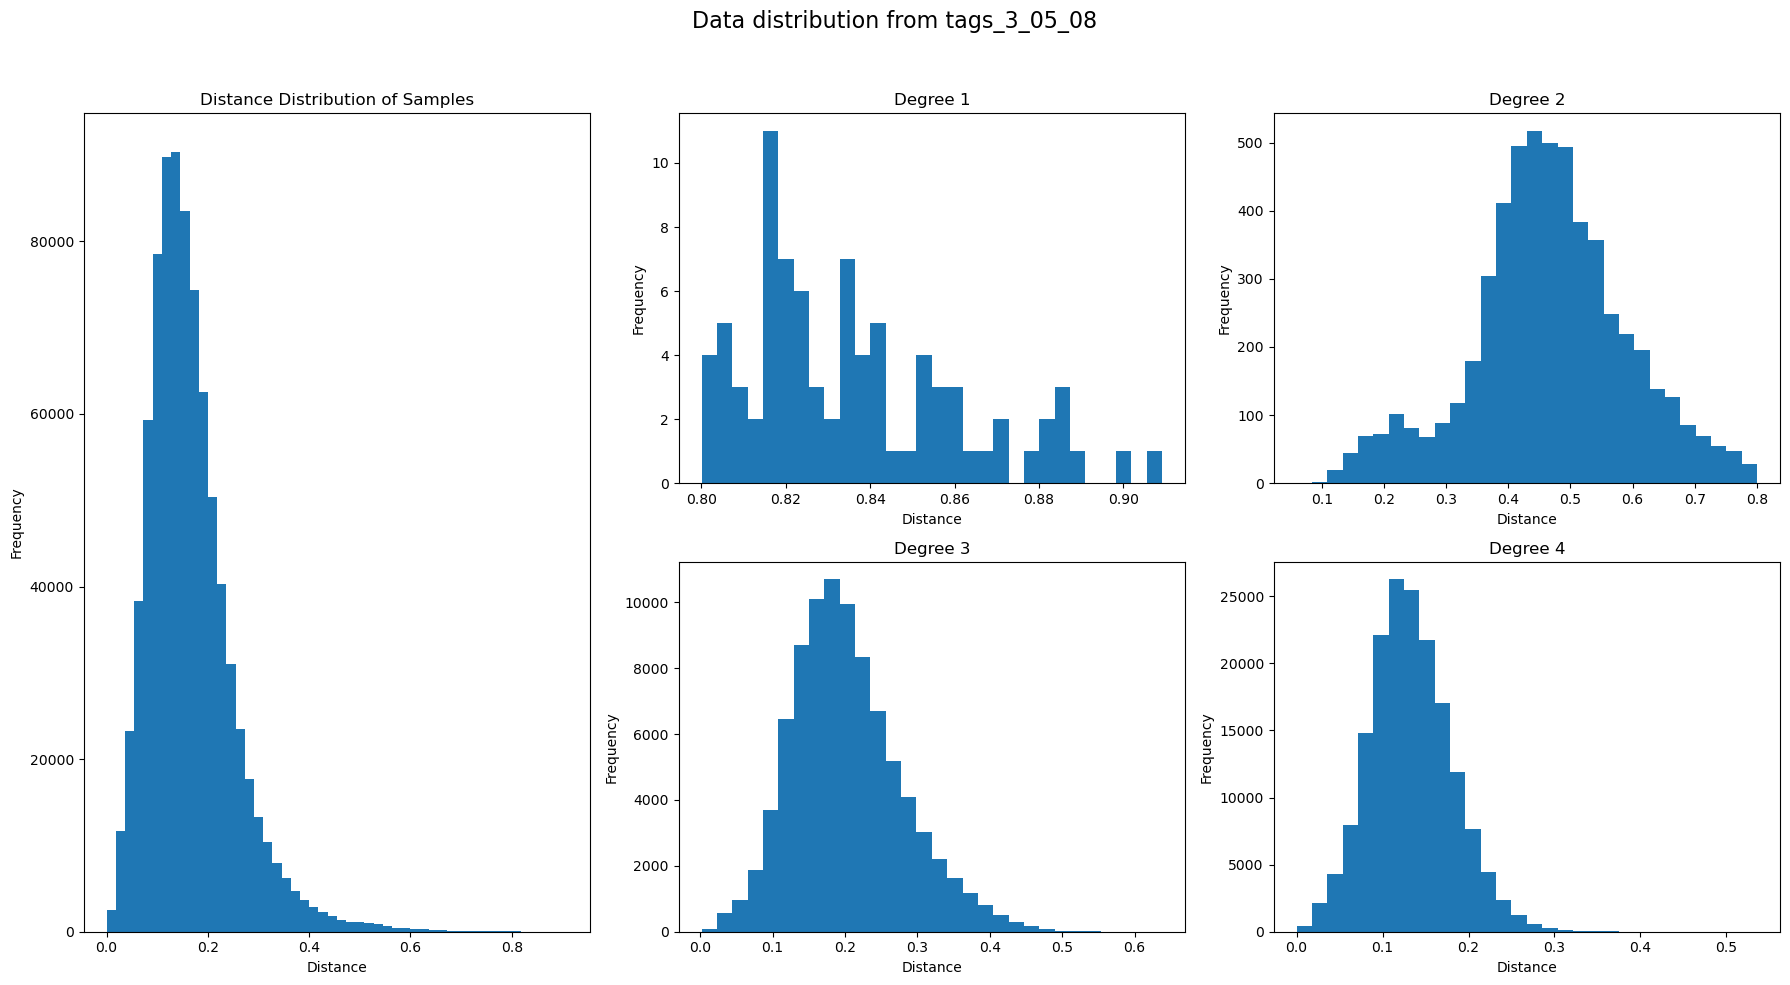

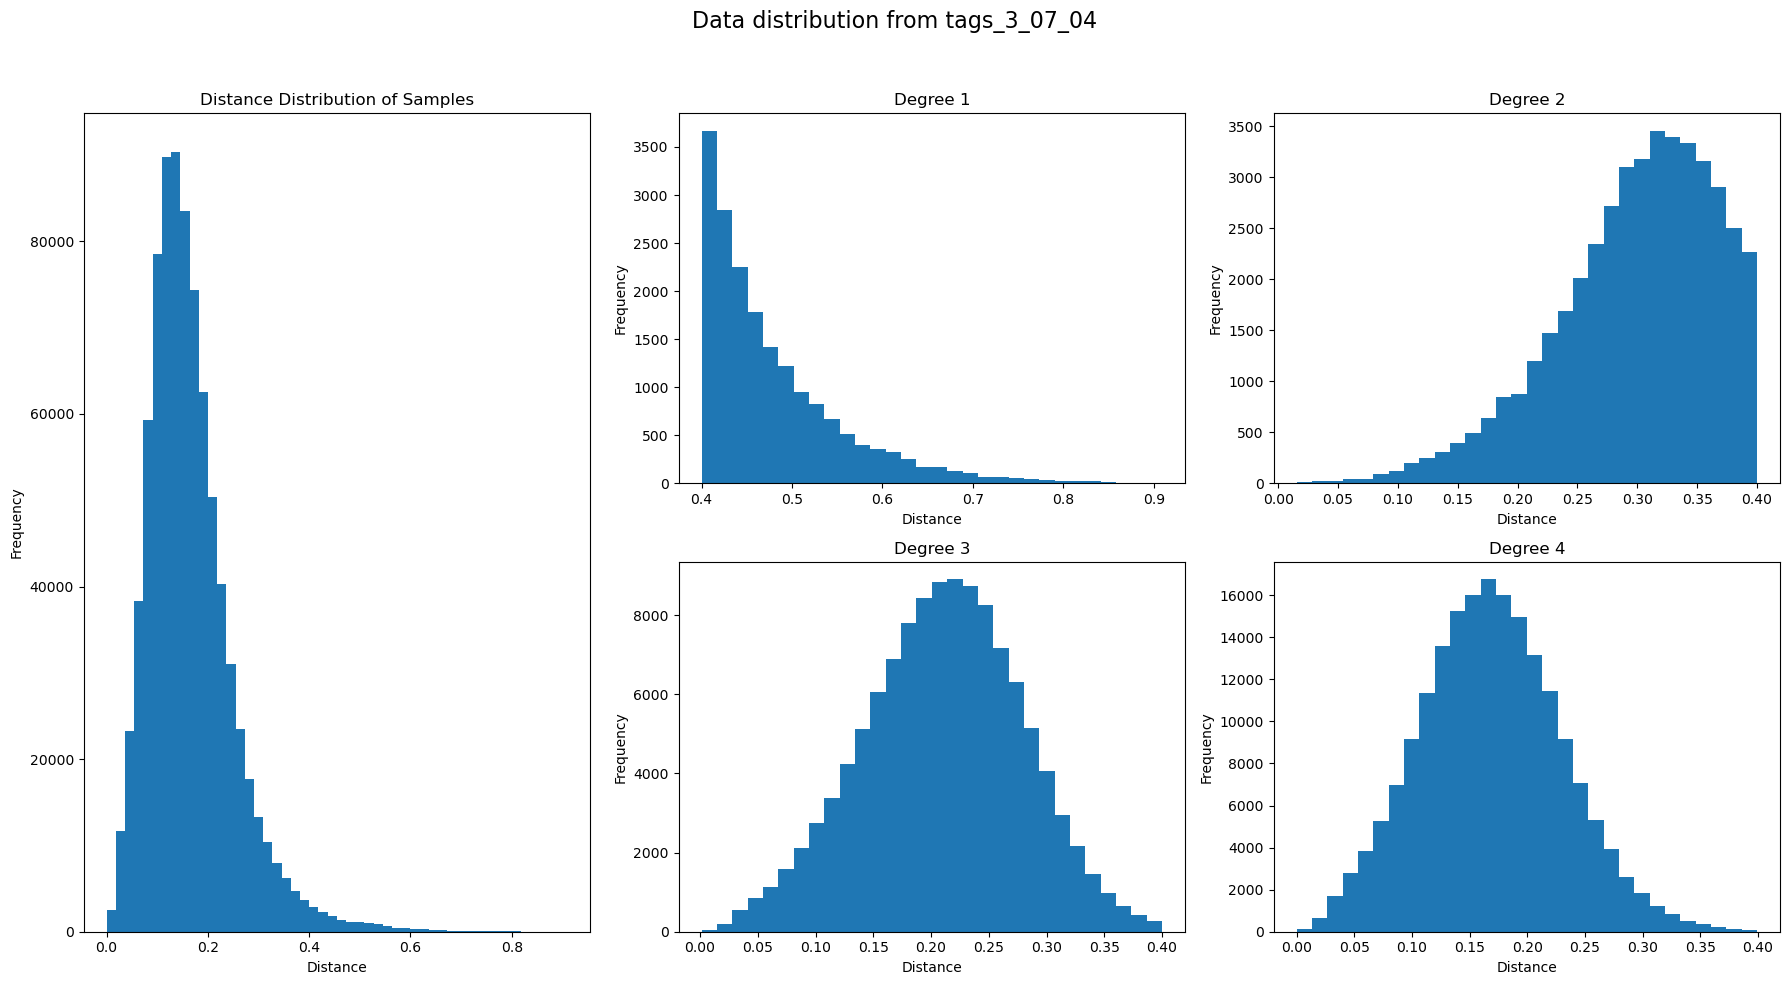

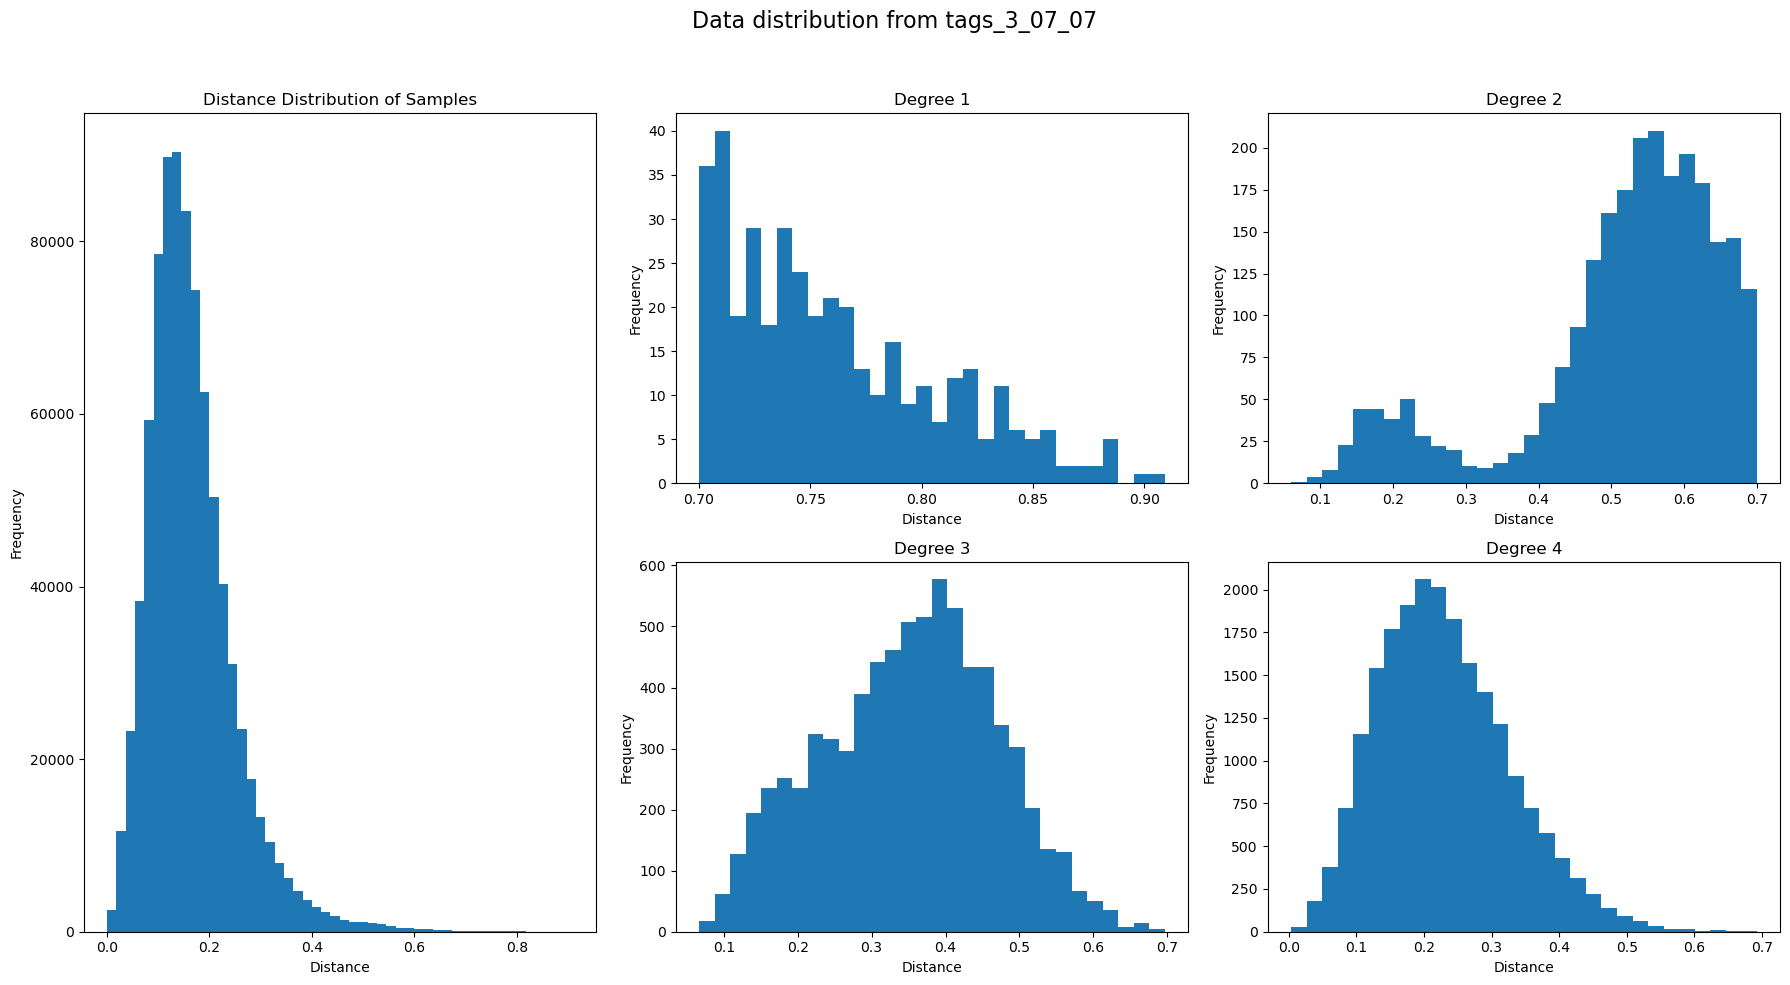

In [32]:
tables = ["tags_3_05_08", "tags_3_07_04", "tags_3_07_07"]

for table in tables:
    fig = plt.figure(figsize=(18,10))
    gs = fig.add_gridspec(2, 3)

    # Sample distribution (spans both rows)
    ax_sample = fig.add_subplot(gs[:, 0])

    distance = cursor.execute("SELECT distance FROM tags").fetchall()
    distance = [row[0] for row in distance]

    ax_sample.hist(distance, bins=50)
    ax_sample.set_title("Distance Distribution of Samples")
    ax_sample.set_xlabel("Distance")
    ax_sample.set_ylabel("Frequency")

    # 2x2 degree plots
    axes = [
        fig.add_subplot(gs[0,1]),
        fig.add_subplot(gs[0,2]),
        fig.add_subplot(gs[1,1]),
        fig.add_subplot(gs[1,2])
    ]

    for i, level in enumerate([1,2,3,4]):
        data = cursor.execute(
            f"SELECT distance FROM {table} WHERE degree = ?", (level,)
        ).fetchall()

        data = [row[0] for row in data]

        axes[i].hist(data, bins=30)
        axes[i].set_title(f"Degree {level}")
        axes[i].set_xlabel("Distance")
        axes[i].set_ylabel("Frequency")

    fig.suptitle(f"Data distribution from {table}", fontsize=16)
    plt.tight_layout(rect=[0,0,1,0.95])
    plt.show()

In [33]:
import numpy as np
from scipy.stats import norm, gaussian_kde

degree_models = {}
degree_priors = {}

for level in sorted_degree:
    data = cursor.execute(
        "SELECT distance FROM tags WHERE degree = ?", (level,)
    ).fetchall()

    data = np.array([row[0] for row in data])

    mu, sigma = norm.fit(data)

    degree_models[level] = (mu, sigma)
    degree_priors[level] = len(data)

In [34]:
total = sum(degree_priors.values())
for k in degree_priors:
    degree_priors[k] /= total

In [35]:
def predict_degree_norm(distance):
    probs = {}

    for k,(mu,sigma) in degree_models.items():
        likelihood = norm.pdf(distance, mu, sigma)
        probs[k] = likelihood * degree_priors[k]

    total = sum(probs.values())

    for k in probs:
        probs[k] /= total

    return probs

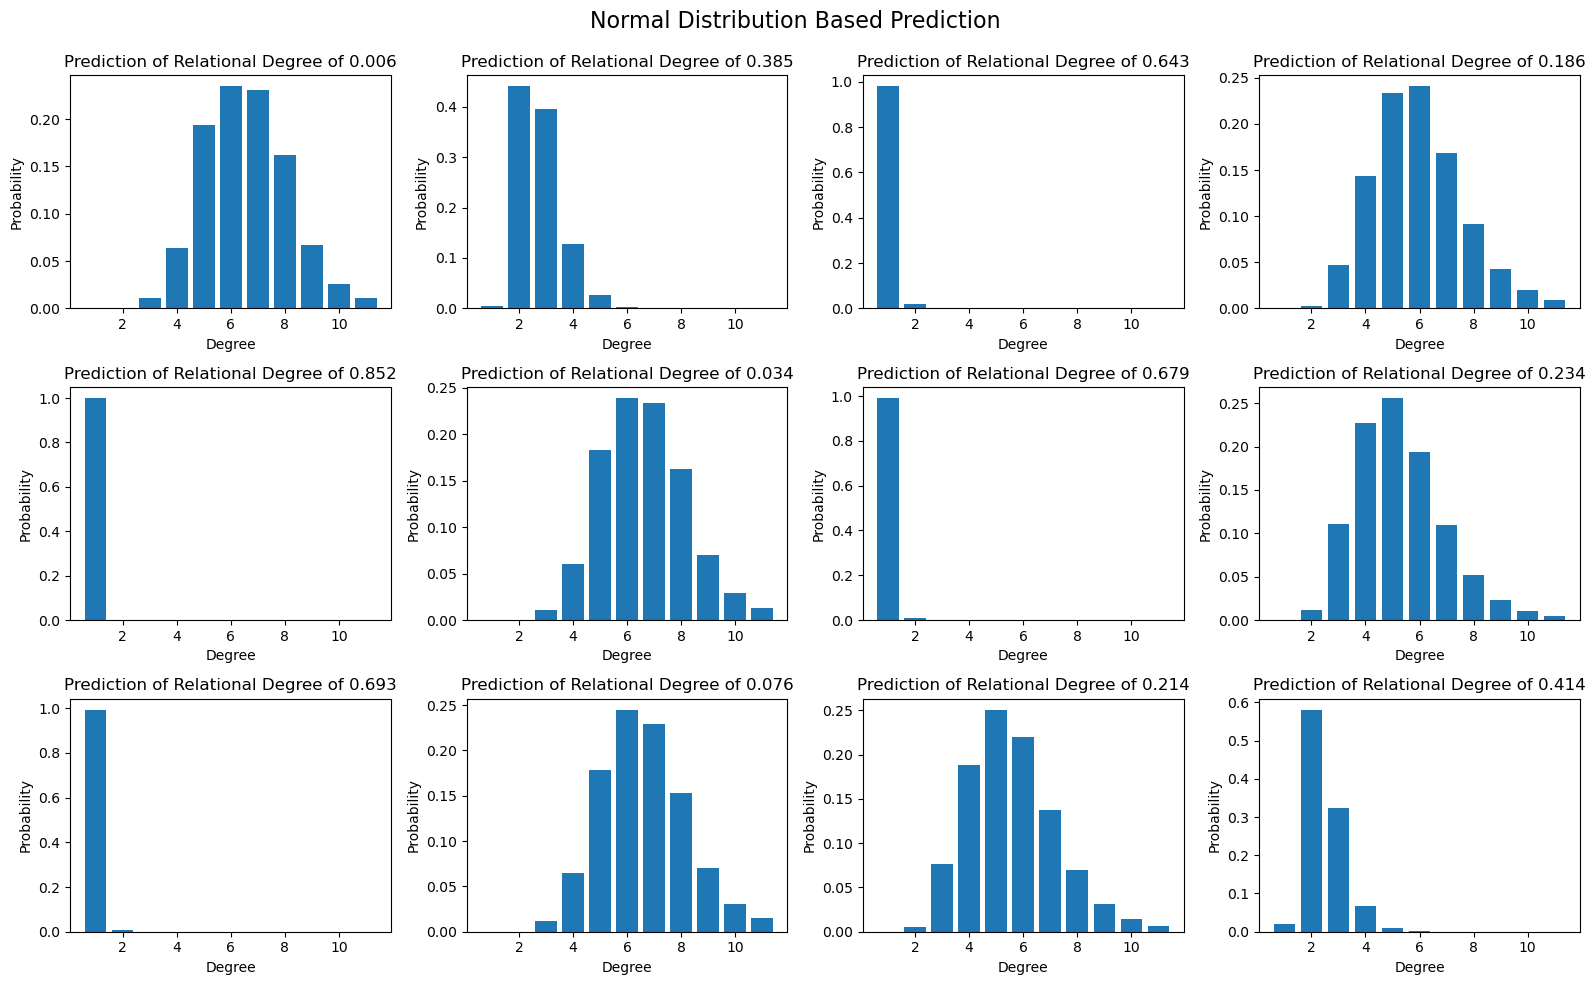

In [36]:
import random

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()
samples = [random.random() for _ in range(len(axes))]

for i, sample in enumerate(samples):
    result = predict_degree_norm(sample)

    degrees = list(result.keys())
    probs = list(result.values())

    axes[i].bar(degrees, probs)
    axes[i].set_title(f"Prediction of Relational Degree of {sample:.3f}")
    axes[i].set_xlabel("Degree")
    axes[i].set_ylabel("Probability")

plt.tight_layout(rect=[0,0,1,0.95])
plt.suptitle("Normal Distribution Based Prediction", fontsize=16)
plt.show()

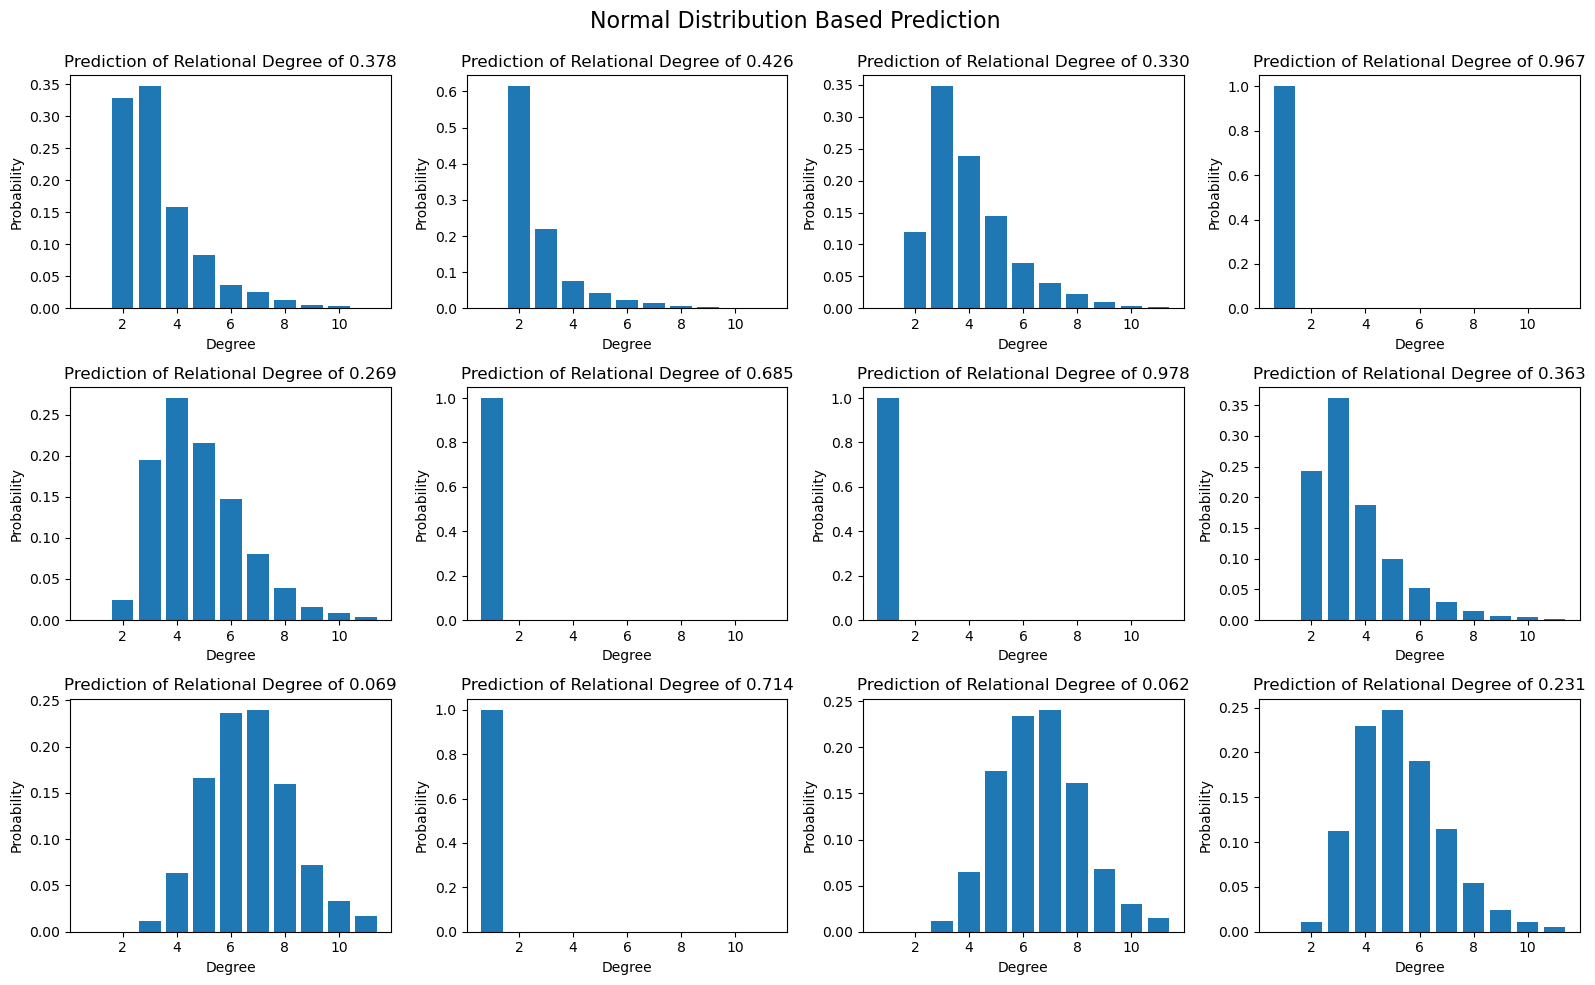

In [37]:
kde_models = {}
degree_priors = {}

for level in sorted_degree:
    data = cursor.execute(
        "SELECT distance FROM tags WHERE degree = ?", (level,)
    ).fetchall()

    data = np.array([row[0] for row in data])

    kde_models[level] = gaussian_kde(data)
    degree_priors[level] = len(data)

# normalize priors
total = sum(degree_priors.values())
for k in degree_priors:
    degree_priors[k] /= total

def predict_degree_kde(distance):

    probs = {}

    for k in kde_models:
        likelihood = kde_models[k](distance)[0]
        probs[k] = likelihood * degree_priors[k]

    total = sum(probs.values())

    for k in probs:
        probs[k] /= total

    return probs

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()
samples = [random.random() for _ in range(len(axes))]

for i, sample in enumerate(samples):
    result = predict_degree_kde(sample)

    degrees = list(result.keys())
    probs = list(result.values())

    axes[i].bar(degrees, probs)
    axes[i].set_title(f"Prediction of Relational Degree of {sample:.3f}")
    axes[i].set_xlabel("Degree")
    axes[i].set_ylabel("Probability")

plt.tight_layout(rect=[0,0,1,0.95])
plt.suptitle("Normal Distribution Based Prediction", fontsize=16)
plt.show()

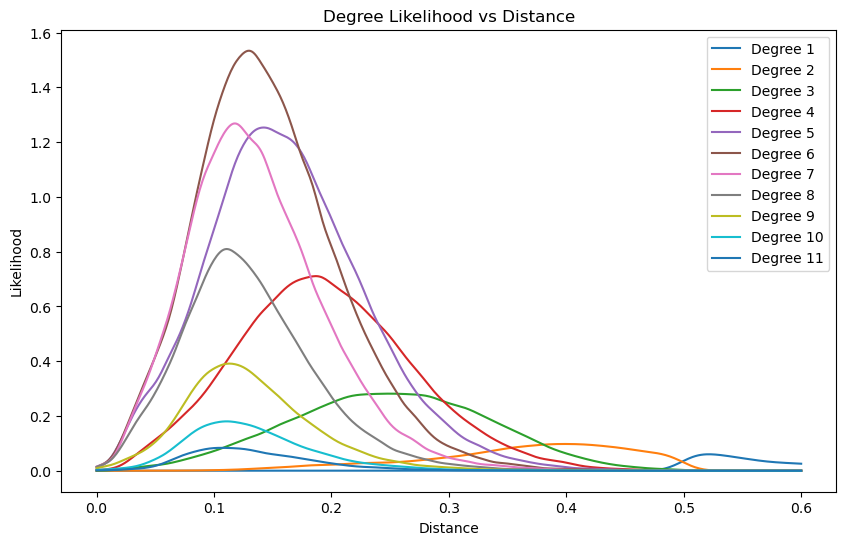

In [38]:
distances = np.linspace(0,0.6,500)

plt.figure(figsize=(10,6))

for k in kde_models:
    probs = [kde_models[k](d)[0] * degree_priors[k] for d in distances]
    plt.plot(distances, probs, label=f"Degree {k}")

plt.xlabel("Distance")
plt.ylabel("Likelihood")
plt.title("Degree Likelihood vs Distance")
plt.legend()
plt.show()